In [70]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import numpy as np

In [71]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 12.8


In [130]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=1.0e12):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        # Return physical stress component explicitly instead of raw first state entry.
        state_hist_raw = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(result, 2))
        state_hist = {str(k): v.torch() for k, v in state_hist_raw.items()}

        if "state/S" in state_hist:
            return state_hist["state/S"][..., 0:1]
        if "state/mixed_state" in state_hist:
            return state_hist["state/mixed_state"][..., 0:1]

        raise KeyError(
            f"Neither state/S nor state/mixed_state found. Available state vars: {sorted(state_hist.keys())}"
        )

In [131]:
nchunk = 50
nmodel = neml2.load_model("new_model_test.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["Bk_X", "C_X", "E_X", "E_Y", "G_X", "G_Y", "H_0_X", "T_0_X", "T_ref_X", "T_ref_Y",
                                                                            "athermal_alpha", "athermal_b", "elasticity_nu", "flow_rate_b", "g_X", "k1_X", "k2_X",
                                                                            "rho_m_rate_L", "sy_X", "tau_p_X", "v_disl_L", "v_disl_a", "v_disl_b", "v_disl_h", "p_X", "q_X", "m_X"]))

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: Bk_X [Scalar][Double][cuda:0]
            Bk_Y [Scalar][Double][cuda:0]
            C_X [Scalar][Double][cuda:0]
            C_Y [Scalar][Double][cuda:0]
            E_X [Scalar][Double][cuda:0]
            E_Y [Scalar][Double][cuda:0]
       

In [132]:
nbatch = 4
ntime = 500
max_strain = 0.4
rates = torch.tensor([1.0e-4, 4.0e-5, 4.0e-3, 1.38e-6], device=device)
temperatures = torch.tensor([293.15, 789.15, 894.15, 973.15], device=device)
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, T in enumerate(temperatures):
    t_label = str(int(T.item() - 273))
    time_values = torch.linspace(0.0, max_strain / rates[i].item(), ntime, device=device)
    strain_values = torch.linspace(0.0, max_strain, ntime, device=device)

    time[:,i,0] = time_values
    loading[:,i,0] = strain_values
    temperature[:,i,0] = T

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")



--- Full Input Tensors ---
time: torch.Size([500, 4, 1])
temperature: torch.Size([500, 4, 1])
loading: torch.Size([500, 4, 6])


In [133]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)

tensor([[[  0.0000],
         [  0.0000],
         [  0.0000],
         [  0.0000]],

        [[  8.3241],
         [  6.8624],
         [  4.9249],
         [  1.8292]],

        [[ 16.3927],
         [ 13.5188],
         [  9.6915],
         [  3.5987]],

        ...,

        [[244.8669],
         [204.1242],
         [142.8989],
         [ 52.1789]],

        [[244.8669],
         [204.1242],
         [142.8989],
         [ 52.1789]],

        [[244.8669],
         [204.1242],
         [142.8990],
         [ 52.1789]]], device='cuda:0')
torch.Size([500, 4, 1])


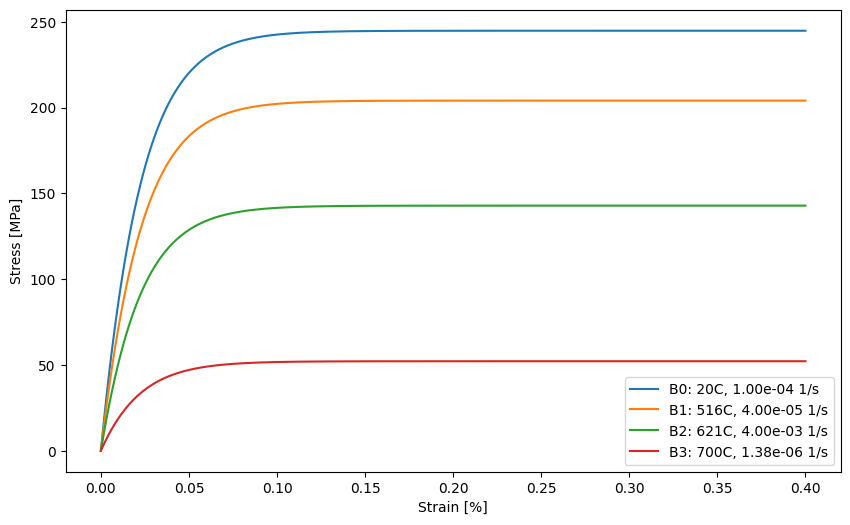

In [134]:
plt.figure(figsize=(10,6))
for i, T in enumerate(temperatures):
    temp_c = str(int(T.item() - 273))
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c}C, {rate_i:.2e} 1/s"
    plt.plot(loading[:, i, 0].cpu().numpy(), stress[:, i, 0].cpu().numpy(), label=label)
plt.xlabel('Strain [%]')
plt.ylabel('Stress [MPa]')
plt.legend()

In [94]:
# Find the yield stress for each temperature
E = nmodel.E_Y.tensor().clone().torch()  # interpolation ordinate for E
sy = nmodel.sy_Y.tensor().clone().torch()  # interpolation ordinate for sy
nu = nmodel.elasticity_nu.tensor().clone().torch()
offset = 0.002

sy_exps = []
E_exps = []

plt.figure(figsize=(10, 6))

for i, T in enumerate(temperatures):
    temp_label = str(int(T.item() - 273))  # Celsius label for display/lookup

    # Calculate actual experimental Young's Modulus
    strain_initial = loading[:5, i, 0].cpu().numpy()
    stress_initial = stress[:5, i, 0].cpu().numpy()
    E_exp = np.polyfit(strain_initial, stress_initial, 1)[0]
    E_exps.append(E_exp)
    print(f"Temp {temp_label}C: E = {E[i]:.2f} MPa, E_exp = {E_exp:.2f} MPa")

Temp 20C: E = 100000.00 MPa, E_exp = 12941.58 MPa
Temp 516C: E = 75000.00 MPa, E_exp = 10273.42 MPa
Temp 621C: E = 67000.00 MPa, E_exp = 7871.19 MPa
Temp 700C: E = 30000.00 MPa, E_exp = 3923.28 MPa


<Figure size 1000x600 with 0 Axes>

Available state variables:
  state/internal/Kp
  state/internal/X
  state/internal/rho_m
  state/mixed_state

Batch 0: T=20.0C, rate=1.000e-04 1/s
rho_m: start=1.000000e+12, end=3.998971e+11
||X||: start=0.000000e+00, end=2.097876e+03
||Kp||: start=0.000000e+00, end=4.584140e-01

Batch 1: T=516.0C, rate=4.000e-05 1/s
rho_m: start=1.000000e+12, end=4.026351e+11
||X||: start=0.000000e+00, end=1.730935e+03
||Kp||: start=0.000000e+00, end=4.552792e-01

Batch 2: T=621.0C, rate=4.000e-03 1/s
rho_m: start=1.000000e+12, end=3.618609e+11
||X||: start=0.000000e+00, end=1.223033e+03
||Kp||: start=0.000000e+00, end=4.625166e-01

Batch 3: T=700.0C, rate=1.380e-06 1/s
rho_m: start=1.000000e+12, end=3.137233e+11
||X||: start=0.000000e+00, end=5.102525e+02
||Kp||: start=0.000000e+00, end=4.647727e-01


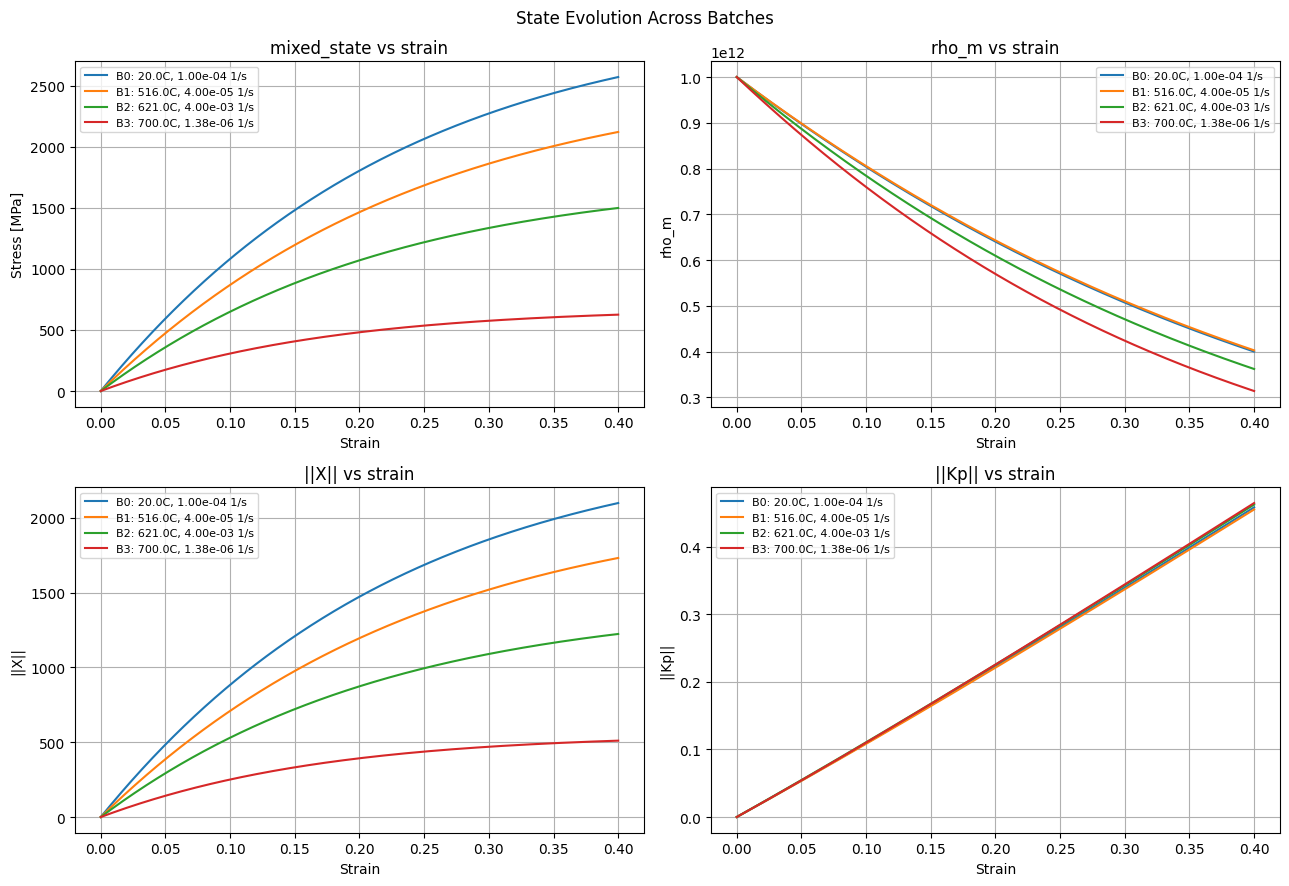

In [ ]:
# Debug: inspect internal-variable evolution over time; overlay all batches on one 2x2 figure
with torch.no_grad():
    dbg_solver = nonlinear.RecursiveNonlinearEquationSolver(
        model.discrete_equations,
        step_generator=nonlinear.StepGenerator(model.nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=model.rtol, atol=model.atol),
    )

    dbg_control = torch.zeros_like(loading)
    dbg_control[..., 1:] = 1.0

    dbg_forces = model.discrete_equations.forces_asm.assemble_by_variable(
        {
            "forces/t": time,
            "forces/control": dbg_control,
            "forces/T": temperature,
            "forces/fixed_values": loading,
        }
    ).torch()

    dbg_state0 = model.discrete_equations.state_asm.assemble_by_variable(
        {
            "state/internal/rho_m": torch.full(
                dbg_forces.shape[1:-1] + (1,), model.initial_rho_m, device=dbg_forces.device
            )
        }
    ).torch()

    dbg_results = nonlinear.solve_adjoint(dbg_solver, dbg_state0, len(dbg_forces), dbg_forces)

# Convert VariableName keys to strings for safe filtering/sorting/indexing
state_hist_raw = model.discrete_equations.state_asm.split_by_variable(neml2.Tensor(dbg_results, 2))
state_hist = {str(k): v for k, v in state_hist_raw.items()}

available_names = sorted(state_hist.keys())
print("Available state variables:")
for name in available_names:
    print(" ", name)

def get_hist(name):
    return state_hist[name].torch() if name in state_hist else None

rho_m = get_hist("state/internal/rho_m")
X = get_hist("state/internal/X")
Kp = get_hist("state/internal/Kp")

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("State Evolution Across Batches")

for i, T in enumerate(temperatures):
    strain_hist = loading[:, i, 0].detach().cpu()
    time_hist = time[:, i, 0].detach().cpu()
    stress11 = stress[:, i, 0].detach().cpu() if stress is not None else None
    rho_m_hist = rho_m[:, i, 0].detach().cpu() if rho_m is not None else None
    x_norm_hist = torch.linalg.norm(X[:, i, :], dim=-1).detach().cpu() if X is not None else None
    kp_norm_hist = torch.linalg.norm(Kp[:, i, :], dim=-1).detach().cpu() if Kp is not None else None

    temp_c = T.item() - 273.15
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c:.1f}C, {rate_i:.2e} 1/s"

    print(f"\nBatch {i}: T={temp_c:.1f}C, rate={rate_i:.3e} 1/s")
    if rho_m_hist is not None:
        print(f"rho_m: start={rho_m_hist[0].item():.6e}, end={rho_m_hist[-1].item():.6e}")
    if x_norm_hist is not None:
        print(f"||X||: start={x_norm_hist[0].item():.6e}, end={x_norm_hist[-1].item():.6e}")
    if kp_norm_hist is not None:
        print(f"||Kp||: start={kp_norm_hist[0].item():.6e}, end={kp_norm_hist[-1].item():.6e}")

    if stress11 is not None:
        ax[0, 0].plot(strain_hist.numpy(), stress11.numpy(), label=label)
    if rho_m_hist is not None:
        ax[0, 1].plot(strain_hist.numpy(), rho_m_hist.numpy(), label=label)
    if x_norm_hist is not None:
        ax[1, 0].plot(strain_hist.numpy(), x_norm_hist.numpy(), label=label)
    if kp_norm_hist is not None:
        ax[1, 1].plot(strain_hist.numpy(), kp_norm_hist.numpy(), label=label)

ax[0, 0].set_title("mixed_state vs strain")
ax[0, 0].set_xlabel("Strain")
ax[0, 0].set_ylabel("Stress [MPa]")
# ax[0, 0].set_xlim([0, 0.02])
ax[0, 0].grid(True)
ax[0, 0].legend(fontsize=8)

ax[0, 1].set_title("rho_m vs strain")
ax[0, 1].set_xlabel("Strain")
ax[0, 1].set_ylabel("rho_m")
# ax[0, 1].set_xlim([0, 100])
ax[0, 1].grid(True)
ax[0, 1].legend(fontsize=8)

ax[1, 0].set_title("||X|| vs strain")
ax[1, 0].set_xlabel("Strain")
ax[1, 0].set_ylabel("||X||")
# ax[1, 0].set_xlim([0, 100])
ax[1, 0].grid(True)
ax[1, 0].legend(fontsize=8)

ax[1, 1].set_title("||Kp|| vs strain")
ax[1, 1].set_xlabel("Strain")
ax[1, 1].set_ylabel("||Kp||")
# ax[1, 1].set_xlim([0, 100])
ax[1, 1].grid(True)
ax[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()